# House Price Prediction

Build a machine learning model to predict house prices using structured housing data.

* Exploratory Data Analysis (EDA)
* Data Cleaning & Feature Engineering
* Model Training (Linear Regression)
* Regularization Improvement (Ridge/Lasso)
* Model Evaluation
* Inference & Predictions

In [1]:
import csv
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_test = pd.read_csv("data/test.csv")
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [3]:
df_train = pd.read_csv("data/train.csv")
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Drop Id columns
df_train.drop(columns=['Id'], inplace=True)
df_test.drop(columns=['Id'], inplace=True)

## Exploratory Data Analysis (EDA)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuil

### Missing Values

In [7]:
print(f"Missing values in train dataset (out of {df_train.shape[0]})")
missing_train = df_train.isnull().sum().sort_values(ascending=False)
print(missing_train[missing_train > 0])

Missing values in train dataset (out of 1460)
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
print(f"Missing values in test dataset (out of {df_test.shape[0]})")
missing_test = df_test.isnull().sum().sort_values(ascending=False)
print(missing_test[missing_test > 0])

Missing values in test dataset (out of 1459)
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageFinish      78
GarageQual        78
GarageCond        78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType2      42
BsmtFinType1      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Functional         2
Utilities          2
BsmtFullBath       2
KitchenQual        1
BsmtFinSF1         1
SaleType           1
TotalBsmtSF        1
GarageCars         1
Exterior2nd        1
Exterior1st        1
GarageArea         1
BsmtUnfSF          1
BsmtFinSF2         1
dtype: int64


### Target Distribution

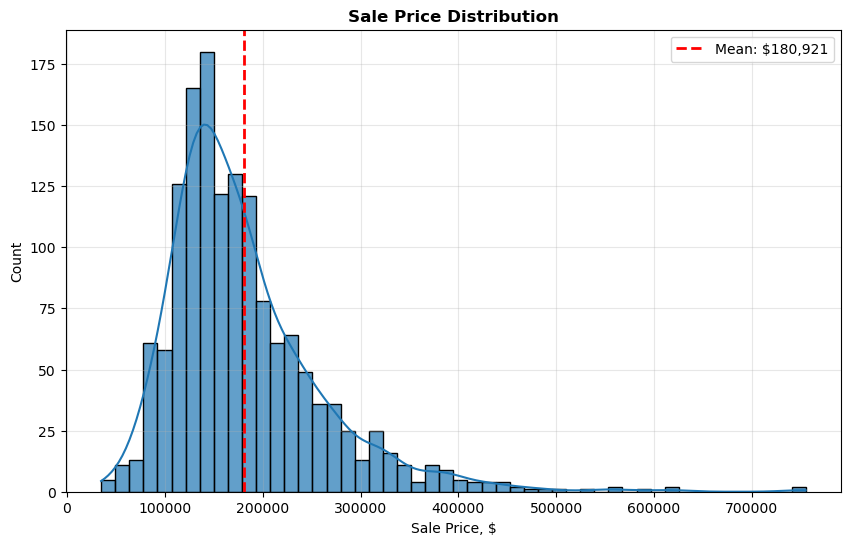

In [9]:
plt.figure(figsize=(10, 6))

mean_price = df_train['SalePrice'].mean()

sns.histplot(data=df_train, x='SalePrice', bins=50, kde=True, edgecolor='black', alpha=0.7)

plt.title('Sale Price Distribution', fontweight='bold')
plt.xlabel('Sale Price, $')
plt.ylabel('Count')
line = plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2)
plt.legend([line], [f'Mean: ${mean_price:,.0f}'])
plt.grid(True, alpha=0.3)
plt.show()

> The sale price distribution is right-skewed, so `SalePrice` should be log transformed.

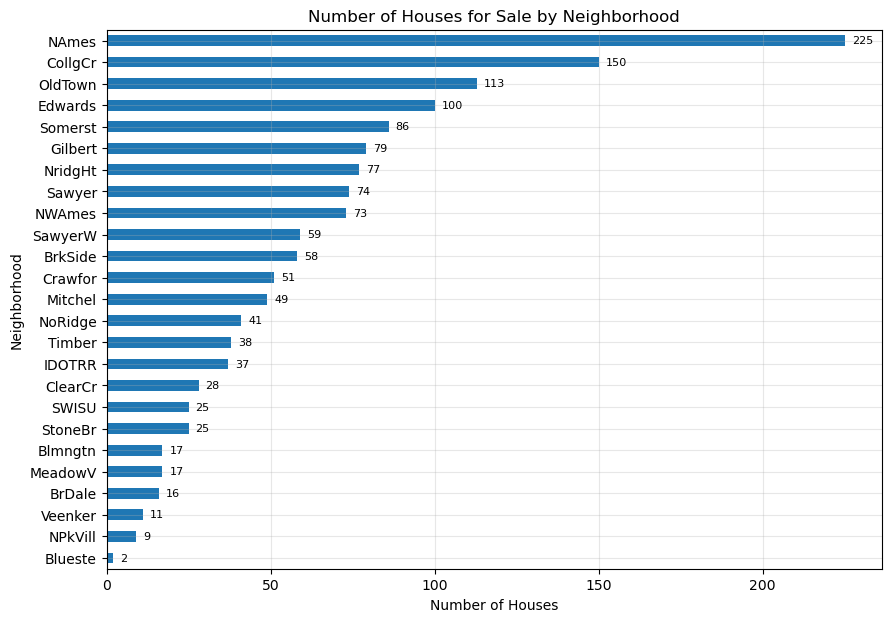

In [10]:
# Number of Houses for Sale by Neighborhood
plt.figure(figsize=(10, 7))

count_by_neighborhood = df_train.groupby("Neighborhood").size()
count_sorted = count_by_neighborhood.sort_values(ascending=True)
ax = count_sorted.plot(kind="barh")

ax.set_xlabel("Number of Houses")
ax.bar_label(ax.containers[0], labels=[x for x in count_sorted], 
             padding=5, fontsize=8)

plt.title("Number of Houses for Sale by Neighborhood")
plt.grid(True, alpha=0.3)
plt.show()

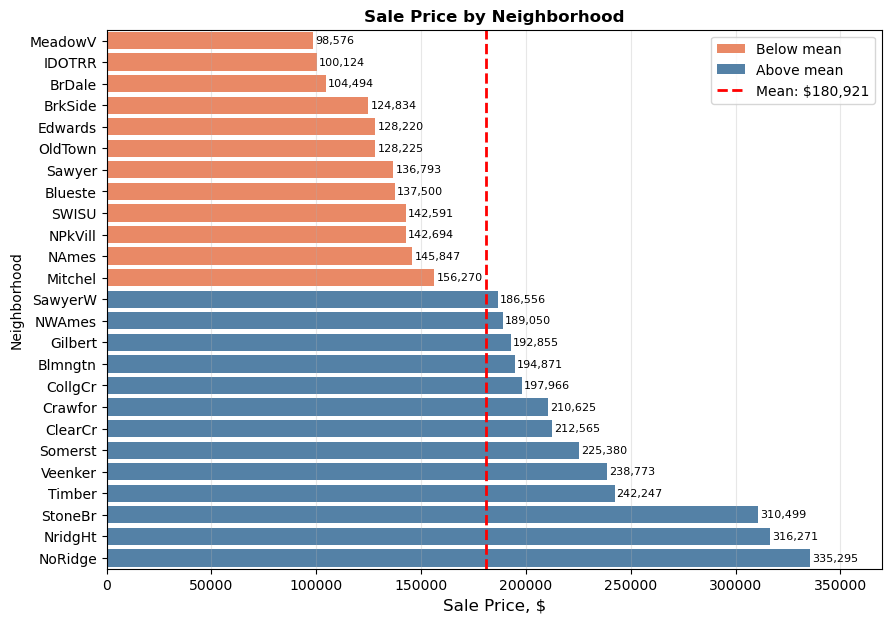

In [11]:
# Sale Price by Neighborhood
plt.figure(figsize=(10, 7))
price_by_neighborhood = df_train.groupby("Neighborhood")["SalePrice"].mean()
price_sorted = price_by_neighborhood.sort_values(ascending=True)

price_df = pd.DataFrame({
    'Neighborhood': price_sorted.index,
    'SalePrice': price_sorted.values,
    'Direction': ['Above mean' if p >= mean_price else 'Below mean' for p in price_sorted.values]
})

ax = sns.barplot(price_df, x='SalePrice', y='Neighborhood',
                 hue='Direction',
                 palette={'Above mean': 'steelblue', 'Below mean': 'coral'})

for i, (val, name) in enumerate(zip(price_df['SalePrice'], price_df['Neighborhood'])):
    ax.text(val + 1000, i, f'{val:,.0f}', va='center', fontsize=8)

xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1] * 1.05) 
    
plt.title('Sale Price by Neighborhood', fontweight='bold')
plt.xlabel('Sale Price, $', fontsize=12)
plt.grid(axis='x', alpha=0.3)

ax.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${mean_price:,.0f}')
ax.legend(loc='upper right', framealpha=0.8)

plt.show()

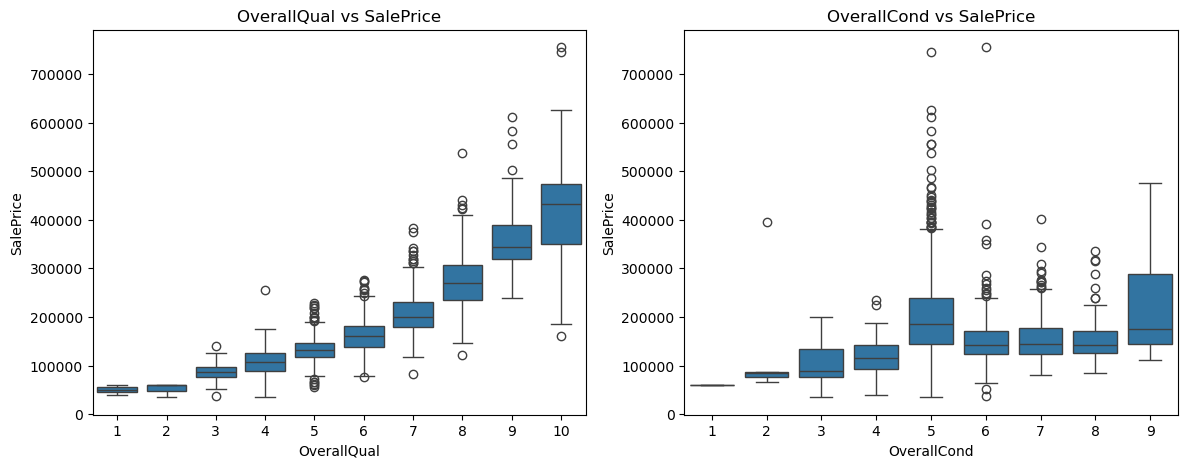

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall quality vs sale price
sns.boxplot(df_train, x='OverallQual', y='SalePrice', ax=axes[0])
axes[0].set_title('OverallQual vs SalePrice')

# Overall condition vs sale price
sns.boxplot(df_train, x='OverallCond', y='SalePrice', ax=axes[1])
axes[1].set_title('OverallCond vs SalePrice')

plt.show()

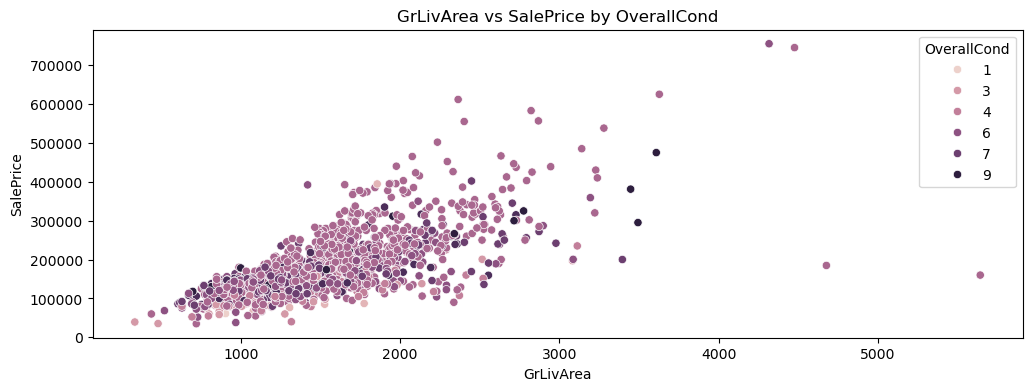

In [13]:
# GrLivArea vs SalePrice by OverallCond
plt.figure(figsize=(12, 4))
sns.scatterplot(df_train, x='GrLivArea', y='SalePrice', hue="OverallCond")
plt.title('GrLivArea vs SalePrice by OverallCond')
plt.show()

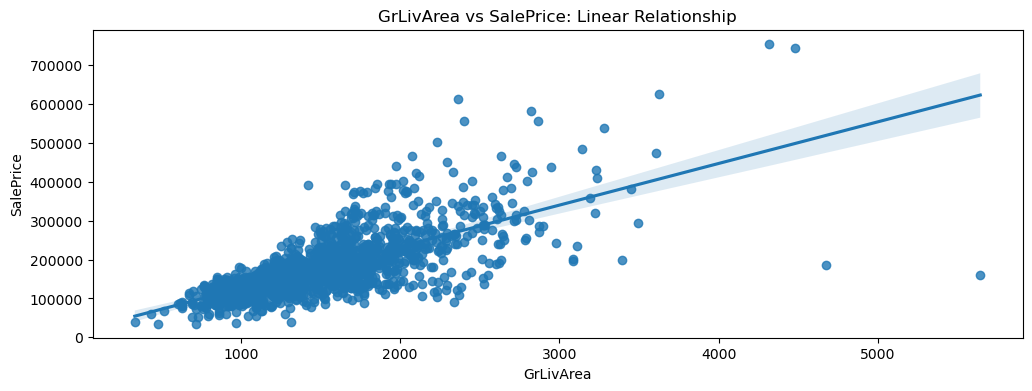

In [14]:
plt.figure(figsize=(12, 4))
sns.regplot(df_train, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice: Linear Relationship')
plt.show()

In [15]:
outliers = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 200000)]

print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'OverallCond', 'SaleCondition']])

      GrLivArea  SalePrice  OverallQual  OverallCond SaleCondition
523        4676     184750           10            5       Partial
1298       5642     160000           10            5       Partial


*Partial sale condition implies that the home was not completed when last assessed (associated with New Homes).*

> Two observations with `GrLivArea` > 4000 and `SalePrice` < 200,000 were identified as outliers. Despite having the largest living areas 
in the dataset, their prices are below average, suggesting non-standard sale conditions. These observations are removed as they 
would negatively bias the regression line.

In [16]:
outliers_idx = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 200000)].index

# Remove outliers
df_train = df_train.drop(outliers_idx)

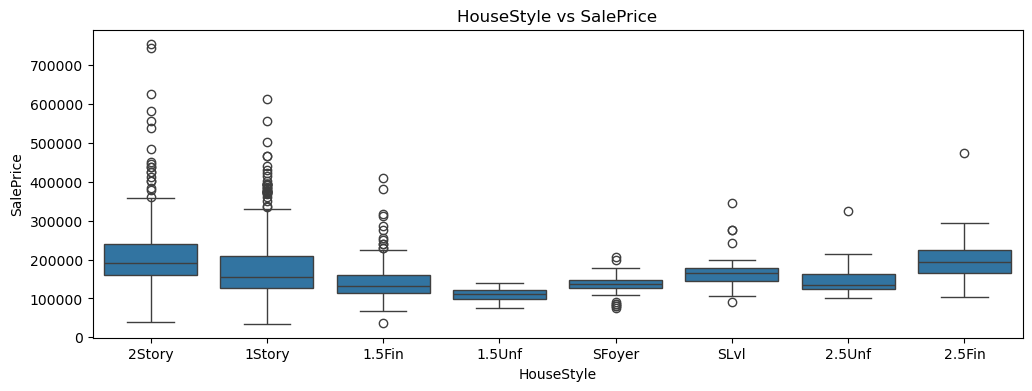

In [17]:
# HouseStyle vs SalePrice
plt.figure(figsize=(12, 4))
sns.boxplot(df_train, x='HouseStyle', y='SalePrice')
plt.title('HouseStyle vs SalePrice')
plt.show()

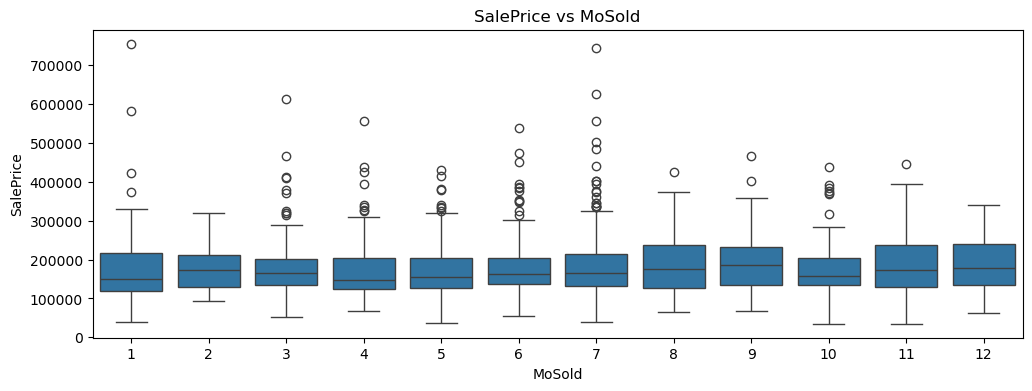

In [18]:
# SalePrice vs MoSold
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_train, x='MoSold', y='SalePrice')
plt.title('SalePrice vs MoSold')
plt.show()

### Data Insights Drawn from EDA

* **Sale Price**

    - `SalePrice` is right-skewed, indicating that most homes are moderately priced with a small number of luxury properties.
    - Log transformation will be applied to `SalePrice` before model training.

* **Neighborhood**

    - Sale price varies widely across neighborhoods.
    - NoRidge, NridgHt, and StoneBr have median prices well above the dataset mean, while MeadowV, IDOTRR, and BrDale are the most affordable.
    - NAmes has the highest number of listings (225), but sits below the mean price — high supply does not imply high value.

* **Overall Quality** and **Overall Condition**

    - `OverallQual` shows a clear relationship with SalePrice: each step up in quality corresponds to a noticeably higher median price, with boxes shifting upward across all 10 levels.
    - `OverallCond`, in contrast, shows no consistent trend: median prices fluctuate across condition levels with no clear direction.

* **Living Area**

    - `GrLivArea` shows a clear positive linear relationship with `SalePrice`: larger homes consistently sell for more.
    - Two outliers are visible in thebottom right corner: homes with GrLivArea > 4,000 but SalePrice < 200,000, which sit far below the regression line. These were removed from the dataset.

* **House Style**

    - 2-story homes command the highest median prices, followed by 1-story homes. 
    - 1.5Unf (1.5 story unfinished) and SFoyer styles are associated with the lowest prices.
      
* **Seasonal Patterns**

    - Months 3, 6, and 7 (spring/summer) show a higher number of outliers, likely reflecting increased market activity during peak selling season.
    - Despite this, the overall price distribution remains consistent year-round, suggesting that `MoSold` is unlikely to be a strong predictor.

## Feature Engineering
### Multicollinearity Analysis

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [20]:
corr_with_price = df_train.select_dtypes(include=np.number).corr()['SalePrice']

In [21]:
print(f"Correlation with SalePrice:\n {corr_with_price.abs().sort_values(ascending=False)}")

Correlation with SalePrice:
 SalePrice        1.000000
OverallQual      0.795774
GrLivArea        0.734968
TotalBsmtSF      0.651153
GarageCars       0.641047
1stFlrSF         0.631530
GarageArea       0.629217
FullBath         0.562165
TotRmsAbvGrd     0.537769
YearBuilt        0.523608
YearRemodAdd     0.507717
GarageYrBlt      0.487156
MasVnrArea       0.482719
Fireplaces       0.469862
BsmtFinSF1       0.409384
LotFrontage      0.370584
WoodDeckSF       0.324758
OpenPorchSF      0.321142
2ndFlrSF         0.320532
HalfBath         0.284590
LotArea          0.268179
BsmtFullBath     0.228459
BsmtUnfSF        0.214460
BedroomAbvGr     0.168245
KitchenAbvGr     0.135946
EnclosedPorch    0.128646
ScreenPorch      0.111415
PoolArea         0.099490
MSSubClass       0.084276
OverallCond      0.077948
MoSold           0.046124
3SsnPorch        0.044568
YrSold           0.028882
LowQualFinSF     0.025625
MiscVal          0.021203
BsmtHalfBath     0.016881
BsmtFinSF2       0.011422
Name: Sal

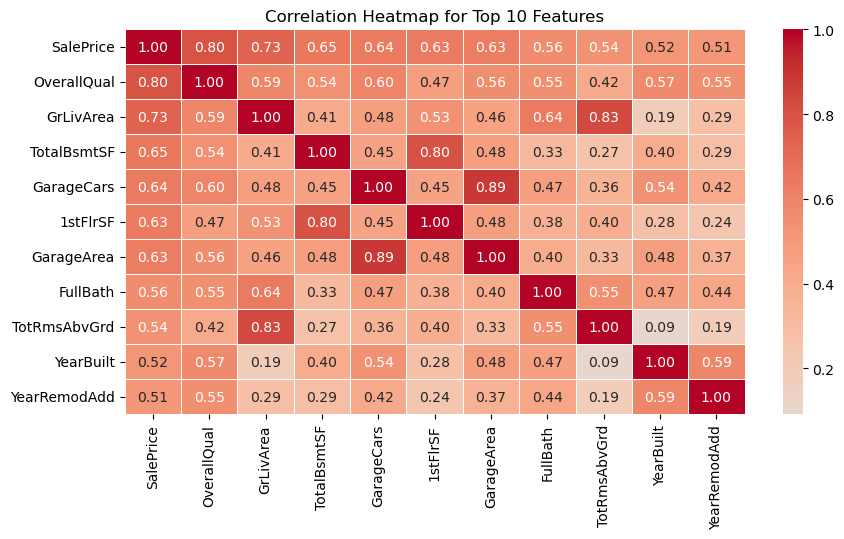

In [22]:
top10_features = corr_with_price.abs().sort_values(ascending=False)[0:11].index

plt.figure(figsize=(10, 5))
sns.heatmap(df_train[top10_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidth=.5)
plt.title('Correlation Heatmap for Top 10 Features')
plt.show()

#### Insights Derived from Correlation Matrix

**Strongest predictors of SalePrice**

The following features have strong correlation with `SalePrice`:
- `OverallQual` (0.80)
- `GrLivArea` (0.73)
- `TotalBsmtSF` (0.65)
- `GarageCars` (0.64)
- `1stFlrSF` and `GarageArea` (both 0.63)
- `YearBuilt` (0.52)
-  `YearRemodAdd` (0.51)

**Multicollinearity concerns**

Several highly correlated feature pairs are:
- `GarageCars` and `GarageArea` (0.89)
- `TotalBsmtSF` and `1stFlrSF` (0.80)
- `GrLivArea` and `TotRmsAbvGrd` (0.83)

These pairs will be investigated further using VIF analysis.

#### VIF Analysis

In [23]:
# Calculate VIF for numeric features
df_vif = (df_train
          .select_dtypes(include=['int64', 'float64'])
          .drop('SalePrice', axis=1)
          .dropna())


def calculate_vif(df):
    df_with_const = add_constant(df)
    
    # RuntimeWarning (divide by zero) is expected for features with perfect multicollinearity (VIF = inf)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        vif_data = pd.DataFrame({
            'feature': df_with_const.columns,
            'VIF': [variance_inflation_factor(df_with_const.values, i) for i in range(df_with_const.shape[1])]
        }).sort_values('VIF', ascending=False).round(2)
        
    vif_data = vif_data[vif_data['feature'] != 'const']
    
    return vif_data


print(calculate_vif(df_vif))

          feature   VIF
15   LowQualFinSF   inf
9      BsmtFinSF1   inf
16      GrLivArea   inf
14       2ndFlrSF   inf
13       1stFlrSF   inf
12    TotalBsmtSF   inf
11      BsmtUnfSF   inf
10     BsmtFinSF2   inf
6       YearBuilt  6.08
23   TotRmsAbvGrd  4.57
25    GarageYrBlt  4.57
26     GarageCars  4.43
27     GarageArea  4.38
4     OverallQual  3.48
19       FullBath  3.13
7    YearRemodAdd  2.75
21   BedroomAbvGr  2.31
17   BsmtFullBath  2.27
20       HalfBath  2.26
5     OverallCond  1.77
1      MSSubClass  1.76
2     LotFrontage  1.72
22   KitchenAbvGr  1.59
24     Fireplaces  1.58
8      MasVnrArea  1.43
30  EnclosedPorch  1.32
3         LotArea  1.29
29    OpenPorchSF  1.27
28     WoodDeckSF  1.24
32    ScreenPorch  1.16
18   BsmtHalfBath  1.16
33       PoolArea  1.11
34        MiscVal  1.10
35         MoSold  1.06
36         YrSold  1.05
31      3SsnPorch  1.03


##### Basement Related Features

According to the dataset description, `TotalBsmtSF` is total square feet of basement area:
* `BsmtFinSF1`: Type 1 finished square feet
* `BsmtFinSF2`: Type 2 finished square feet
* `BsmtUnfSF`: Unfinished square feet of basement area

In [24]:
# Make sure that TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF
bsmt_check = (df_train['BsmtFinSF1'] + df_train['BsmtFinSF2'] + df_train['BsmtUnfSF'])
print(f"TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF: {(df_train['TotalBsmtSF'] - bsmt_check).sum() == 0}")

TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF: True


In [25]:
# Drop redundant basement columns
bsmt_cols_to_drop = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
df_vif = df_vif.drop(bsmt_cols_to_drop, axis=1)

In [26]:
# Recheck VIF
print(calculate_vif(df_vif))

          feature   VIF
10       1stFlrSF   inf
11       2ndFlrSF   inf
12   LowQualFinSF   inf
13      GrLivArea   inf
6       YearBuilt  6.04
22    GarageYrBlt  4.57
20   TotRmsAbvGrd  4.56
23     GarageCars  4.41
24     GarageArea  4.38
9     TotalBsmtSF  3.99
4     OverallQual  3.44
16       FullBath  3.13
7    YearRemodAdd  2.70
18   BedroomAbvGr  2.28
17       HalfBath  2.25
1      MSSubClass  1.76
5     OverallCond  1.75
2     LotFrontage  1.72
19   KitchenAbvGr  1.59
21     Fireplaces  1.58
8      MasVnrArea  1.41
27  EnclosedPorch  1.32
14   BsmtFullBath  1.31
3         LotArea  1.28
26    OpenPorchSF  1.26
25     WoodDeckSF  1.23
29    ScreenPorch  1.15
30       PoolArea  1.11
31        MiscVal  1.10
15   BsmtHalfBath  1.09
32         MoSold  1.06
33         YrSold  1.05
28      3SsnPorch  1.03


##### Living Area Related Features
According to the dataset description, `GrLivArea` is above ground living area square feet and is sum of:
* `1stFlrSF`: First Floor square feet
* `2ndFlrSF`: Second floor square feet
* `LowQualFinSF`: Low quality finished square feet (all floors)

In [27]:
# Make sure that GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF
grlivarea_check = (df_train['1stFlrSF'] + df_train['2ndFlrSF'] + df_train['LowQualFinSF'])
print(f"GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF: {(df_train['GrLivArea'] - grlivarea_check).sum() == 0}")

GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF: True


In [28]:
# Drop redundant living area columns
area_cols_to_drop = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']
df_vif = df_vif.drop(area_cols_to_drop, axis=1)

In [29]:
# Recheck VIF
print(calculate_vif(df_vif))

          feature   VIF
10      GrLivArea  6.96
6       YearBuilt  5.89
17   TotRmsAbvGrd  4.56
19    GarageYrBlt  4.49
20     GarageCars  4.40
21     GarageArea  4.37
4     OverallQual  3.43
13       FullBath  3.06
7    YearRemodAdd  2.69
9     TotalBsmtSF  2.46
15   BedroomAbvGr  2.24
14       HalfBath  1.87
5     OverallCond  1.74
1      MSSubClass  1.71
2     LotFrontage  1.70
18     Fireplaces  1.53
16   KitchenAbvGr  1.51
8      MasVnrArea  1.40
11   BsmtFullBath  1.31
24  EnclosedPorch  1.31
3         LotArea  1.28
23    OpenPorchSF  1.26
22     WoodDeckSF  1.23
26    ScreenPorch  1.15
27       PoolArea  1.10
28        MiscVal  1.10
12   BsmtHalfBath  1.09
29         MoSold  1.06
30         YrSold  1.05
25      3SsnPorch  1.03


In [30]:
# Check the correlation between GrLivArea and TotRmsAbvGrd
print("Correlation between GrLivArea and TotRmsAbvGrd")
print(df_train[['GrLivArea', 'TotRmsAbvGrd']].corr().round(2))

Correlation between GrLivArea and TotRmsAbvGrd
              GrLivArea  TotRmsAbvGrd
GrLivArea          1.00          0.83
TotRmsAbvGrd       0.83          1.00


In [31]:
# Check the correlation with SalePrice
print(df_train[['GrLivArea', 'TotRmsAbvGrd', 'SalePrice']].corr()['SalePrice'].round(2))

GrLivArea       0.73
TotRmsAbvGrd    0.54
SalePrice       1.00
Name: SalePrice, dtype: float64


There is a strong collinearity between `GrLivArea` and `TotRmsAbvGrd` (0.83). 

The correlation between `GrLivArea` and `SalePrice` is a bit higher that the one between `TotRmsAbvGrd` and `SalePrice` (0.73 vs 0.54), but I still want to calculate each of these features partial correlation with `SalePrice` to determine which feature to drop.

In [32]:
try:
    from pingouin import partial_corr, pcorr
except ImportError:
    !pip install pingouin
    from pingouin import partial_corr, pcorr

In [33]:
partial_corr_matrix = pcorr(df_train[['GrLivArea', 'TotRmsAbvGrd', 'SalePrice']])
print(f"Partial Correlation with SalePrice\n")
print(partial_corr_matrix.loc[['GrLivArea', 'TotRmsAbvGrd'], 'SalePrice'].round(2))

Partial Correlation with SalePrice

GrLivArea       0.61
TotRmsAbvGrd   -0.19
Name: SalePrice, dtype: float64


The partial correlation with `SalePrice` shows that `GrLivArea` has a significant unique contribution (0.61) after controlling for `TotRmsAbvGrd`, while 
`TotRmsAbvGrd` has almost no unique contribution (-0.19) after controlling for `GrLivArea`. Therefore, `TotRmsAbvGrd` does not provide information beyond what is already provided by `GrLivArea`. Thus, `TotRmsAbvGrd` is to be dropped.

In [34]:
df_vif.drop('TotRmsAbvGrd', inplace=True, axis=1)

In [35]:
# Recheck VIF
print(calculate_vif(df_vif))

          feature   VIF
6       YearBuilt  5.86
10      GrLivArea  5.23
18    GarageYrBlt  4.49
19     GarageCars  4.39
20     GarageArea  4.37
4     OverallQual  3.40
13       FullBath  3.06
7    YearRemodAdd  2.69
9     TotalBsmtSF  2.44
15   BedroomAbvGr  1.88
14       HalfBath  1.87
5     OverallCond  1.74
2     LotFrontage  1.70
1      MSSubClass  1.70
17     Fireplaces  1.53
16   KitchenAbvGr  1.40
8      MasVnrArea  1.40
11   BsmtFullBath  1.31
23  EnclosedPorch  1.30
3         LotArea  1.28
22    OpenPorchSF  1.26
21     WoodDeckSF  1.23
25    ScreenPorch  1.15
27        MiscVal  1.09
26       PoolArea  1.09
12   BsmtHalfBath  1.09
28         MoSold  1.06
29         YrSold  1.05
24      3SsnPorch  1.03


##### Garage Related Features

In [36]:
df_train[['YearBuilt', 'GarageYrBlt', 'GarageArea', 'GarageCars']].corr().round(2)

,YearBuilt,GarageYrBlt,GarageArea,GarageCars
YearBuilt,1.00,0.83,0.48,0.54
GarageYrBlt,0.83,1.00,0.57,0.59
GarageArea,0.48,0.57,1.00,0.89
GarageCars,0.54,0.59,0.89,1.00


In [37]:
partial_corr_matrix = pcorr(df_train[['YearBuilt', 'GarageYrBlt', 'SalePrice']])
print(f"Partial Correlation for YearBuilt and GarageYrBlt:\n")
print(partial_corr_matrix.loc[['YearBuilt', 'GarageYrBlt'], 'SalePrice'].round(2))

Partial Correlation for YearBuilt and GarageYrBlt:

YearBuilt      0.26
GarageYrBlt    0.13
Name: SalePrice, dtype: float64


> `GarageYrBlt` is strongly correlated with `YearBuilt` (0.83), indicating that garages are typically built alongside the house. Partial correlation analysis shows that `YearBuilt` retains a stronger unique relationship with `SalePrice` (0.26 vs 0.13 for `GarageYrBlt`) after controlling for each other.
> 
> Therefore, `GarageYrBlt` is dropped in favor of `YearBuilt`.

In [38]:
# Drop GarageYrBlt
df_vif.drop('GarageYrBlt', inplace=True, axis=1)

# Recheck VIF
calculate_vif(df_vif)

,feature,VIF
10,GrLivArea,5.23
6,YearBuilt,4.51
18,GarageCars,4.39
19,GarageArea,3.98
4,OverallQual,3.39
13,FullBath,3.05
7,YearRemodAdd,2.55
9,TotalBsmtSF,2.43
15,BedroomAbvGr,1.88
14,HalfBath,1.87


In [39]:
partial_corr_matrix = pcorr(df_train[['GarageArea', 'GarageCars', 'SalePrice']])
print(f"Partial Correlation with SalePrice\n")
print(partial_corr_matrix.loc[['GarageArea', 'GarageCars'], 'SalePrice'].round(2))

Partial Correlation with SalePrice

GarageArea    0.17
GarageCars    0.23
Name: SalePrice, dtype: float64


> `GarageArea` and `GarageCars` are highly correlated (0.89). Partial correlation analysis shows that `GarageCars` has a stronger unique relationship with `SalePrice` (0.23 vs 0.17 for `GarageArea`) after controlling for each other.
>
> Therefore, `GarageArea` is dropped in favor of `GarageCars`.

In [40]:
# Drop GarageArea
df_vif.drop('GarageArea', inplace=True, axis=1)

# Recheck VIF
calculate_vif(df_vif)

,feature,VIF
10,GrLivArea,5.17
6,YearBuilt,4.50
4,OverallQual,3.39
13,FullBath,3.05
7,YearRemodAdd,2.54
9,TotalBsmtSF,2.42
18,GarageCars,2.12
15,BedroomAbvGr,1.86
14,HalfBath,1.86
5,OverallCond,1.72


Considering `HouseAge`=`YrSold` - `YearBuilt` rather than `YearBuilt` is common practice in real estate price modeling: age is more meaningful than year of construction from a buyer's perspective. 

In [41]:
df_train['HouseAge'] = df_train['YrSold'] - df_train['YearBuilt']
print("Pearson correlation with SalePrice")
print(df_train[['YearBuilt', 'HouseAge', 'SalePrice']].corr()['SalePrice'].round(2))

Pearson correlation with SalePrice
YearBuilt    0.52
HouseAge    -0.52
SalePrice    1.00
Name: SalePrice, dtype: float64


>`HouseAge` directly expresses how old the house was at the time of sale, making the coefficient more intuitive: each additional year of age is expected to decrease the sale price. 
>
> Therefore, `YearBuilt` is replaced with `HouseAge` to improve model interpretability.

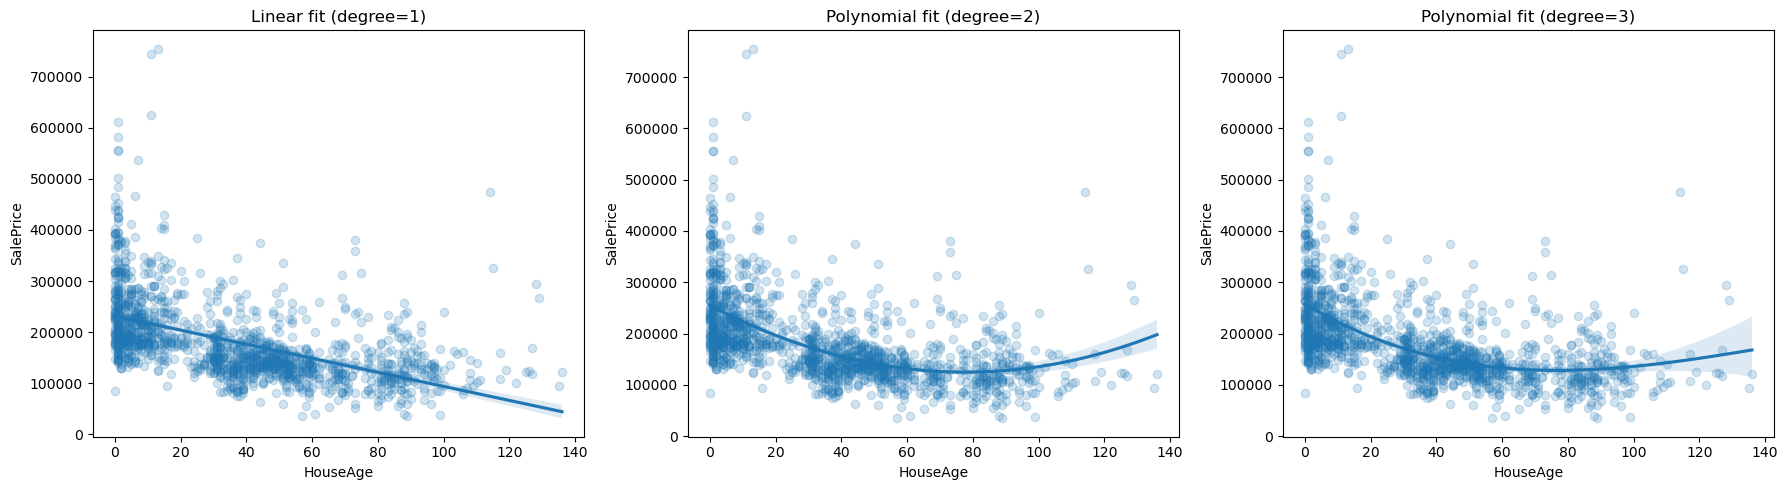

In [42]:
# Explore a relationship between HouseAge and SalePrice
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df_train, x='HouseAge', y='SalePrice', order=1, ax=axes[0], scatter_kws={'alpha': 0.2})
axes[0].set_title('Linear fit (degree=1)')

sns.regplot(data=df_train, x='HouseAge', y='SalePrice', order=2, ax=axes[1], scatter_kws={'alpha': 0.2})
axes[1].set_title('Polynomial fit (degree=2)')

sns.regplot(data=df_train, x='HouseAge', y='SalePrice', order=3, ax=axes[2], scatter_kws={'alpha': 0.2})
axes[2].set_title('Polynomial fit (degree=3)')

plt.tight_layout()
plt.show()

> The Pearson correlation (-0.52) captures the overall linear trend, but the polynomial fit (degree=3) reveals a more complex relationship: prices decline steeply for homes aged 15–60 years, then stabilize for older properties. Higher degree polynomials (4+) were not explored as they risk 
overfitting to noise rather than capturing the true underlying pattern.
>
> The linear model is likely to underestimate prices for very new homes and overestimate for very old ones.

In [43]:
df_test['HouseAge'] = df_test['YrSold'] - df_test['YearBuilt']
df_train['HouseAge'] = df_train['YrSold'] - df_train['YearBuilt']

# House age validation
print(f"Negative HouseAge in train: {(df_train['HouseAge'] < 0).sum()}")
print(f"Negative HouseAge in test: {(df_test['HouseAge'] < 0).sum()}")
print(f"\nTrain HouseAge range: {df_train['HouseAge'].min()}–{df_train['HouseAge'].max()}")
print(f"Test HouseAge range: {df_test['HouseAge'].min()}–{df_test['HouseAge'].max()}")

Negative HouseAge in train: 0
Negative HouseAge in test: 1

Train HouseAge range: 0–136
Test HouseAge range: -1–129


One test record has `HouseAge` = -1 (YearBuilt > YrSold, suggesting data entry error). This value is to be clipped to 0 as the house was effectively new at the time of sale.

In [44]:
# Fix data anomaly: clip negative HouseAge values to 0
df_test['HouseAge'] = df_test['HouseAge'].clip(lower=0)

# Drop redundant columns
df_train = df_train.drop(['YearBuilt', 'YrSold'], axis=1)
df_test = df_test.drop(['YearBuilt', 'YrSold'], axis=1)

In [45]:
# Recheck VIF
calculate_vif(df_vif)

,feature,VIF
10,GrLivArea,5.17
6,YearBuilt,4.50
4,OverallQual,3.39
13,FullBath,3.05
7,YearRemodAdd,2.54
9,TotalBsmtSF,2.42
18,GarageCars,2.12
15,BedroomAbvGr,1.86
14,HalfBath,1.86
5,OverallCond,1.72


#### Feature Removal Based on VIF Analysis

VIF analysis identified several sources of multicollinearity. 
* Composite features were removed where a summary feature already captures the same information
    - `TotalBsmtSF` replaces its components
    - `GrLivArea` replaces its floor-level components
    
* Among correlated pairs, the feature with the lower unique contribution to SalePrice was dropped:
    - `GarageYrBlt` over `YearBuilt`
    - `GarageArea` over `GarageCars`
    - `TotRmsAbvGrd` over `GrLivArea`

* `YearBuilt` and `YrSold` were replaced by `HouseAge` to improve interpretability of the model

In [46]:
cols_to_drop = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', # Basement components (TotalBsmtSF = sum of parts)
    '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',  # Floor components (GrLivArea = sum of parts)
    'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea' # Multicollinear
]

df_train = df_train.drop(cols_to_drop, axis=1)
df_test = df_test.drop(cols_to_drop, axis=1)

## Data Preprocessing

### Missing Categorical Values

Base on dataset description, for some categorical features, `NA`/`None` means the absence of feature, not the absence of value.

In [47]:
# NaN = absence of feature
cat_no_feature = [
    'Alley', # No alley access
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', # No Basement
    'FireplaceQu', # No Fireplace
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', # No Garage
    'MasVnrType', # None
    'PoolQC', # No Pool
    'Fence',  # No Fence
    'MiscFeature', # None
]

In [48]:
missing_cat_train = df_train.select_dtypes(include=['object']).isnull().sum()
missing_cat_test = df_test.select_dtypes(include=['object']).isnull().sum()
print(f"Missing categorical values in train data:\n{missing_cat_train[missing_cat_train > 0]}")
print(f"\nMissing categorical values in test data:\n{missing_cat_test[missing_cat_test > 0]}")

Missing categorical values in train data:
Alley           1367
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1452
Fence           1177
MiscFeature     1404
dtype: int64

Missing categorical values in test data:
MSZoning           4
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageFinish      78
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64


In [49]:
# Find truly missing values in train data
missing_cat_cols_train = missing_cat_train[missing_cat_train > 0].index.tolist()
cat_truly_missing_train = [col for col in missing_cat_cols_train if col not in cat_no_feature]

# Find truly missing values in test data
missing_cat_cols_test = missing_cat_test[missing_cat_test > 0].index.tolist()
cat_truly_missing_test = [col for col in missing_cat_cols_test if col not in cat_no_feature]

print(f"Categories with truly missing values in train data: {cat_truly_missing_train}")
print(f"\nCategories with truly missing values in test data: {cat_truly_missing_test}")

Categories with truly missing values in train data: ['Electrical']

Categories with truly missing values in test data: ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']


In [50]:
cat_truly_missing = list(set(
    [col for col in missing_cat_cols_train if col not in cat_no_feature] +
    [col for col in missing_cat_cols_test if col not in cat_no_feature]
))

print(f"Categories with truly missing values:\n {cat_truly_missing}")

Categories with truly missing values:
 ['Functional', 'KitchenQual', 'SaleType', 'Exterior2nd', 'Electrical', 'MSZoning', 'Exterior1st', 'Utilities']


In [51]:
cat_all = df_train.select_dtypes(include='object').columns.tolist()
cat_no_missing = [col for col in cat_all if col not in cat_no_feature and col not in cat_truly_missing]
print(f"Categories with no missing values:\n {cat_no_missing}")

Categories with no missing values:
 ['Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'PavedDrive', 'SaleCondition']


### Missing Numeric Values

In [52]:
num_features = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col != 'SalePrice']

In [53]:
print(num_features)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'HouseAge']


In [54]:
missing_numeric_train = df_train.select_dtypes(include=['int64', 'float64']).isnull().sum()
missing_numeric_test = df_test.select_dtypes(include=['int64', 'float64']).isnull().sum()

print("Missing numeric values in train data:")
print(missing_numeric_train[missing_numeric_train > 0])

print("\nMissing numeric values in test data:")
print(missing_numeric_test[missing_numeric_test > 0])

Missing numeric values in train data:
LotFrontage    259
MasVnrArea       8
dtype: int64

Missing numeric values in test data:
LotFrontage     227
MasVnrArea       15
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
dtype: int64


Numeric missing values are to be filled based on the nature of the missing data:

* **Zero**

    `MasVnrArea`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath`, `GarageCars` — a missing value indicates the absence of the feature (no veneer, no basement, no garage).

* **Median**

    `LotFrontage` is a genuine missing measurement, as every property has street access.

In [55]:
num_fill_with_zero = ['LotFrontage']
num_fill_with_median = [col for col in num_features if col not in num_fill_with_zero]

In [56]:
# Save cleaned data
train_clean = df_train.copy()
test_clean = df_test.copy()

### Preprocessing Pipelines

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [58]:
# Pipelines for numeric features
numeric_median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_zero_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

In [59]:
# Pipelines for categorical features
cat_no_feature_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

cat_truly_missing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

cat_no_missing_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

In [60]:
preprocessor = ColumnTransformer([
    ('numeric_median', numeric_median_pipeline, num_fill_with_median),
    ('numeric_zero', numeric_zero_pipeline, num_fill_with_zero),
    ('cat_no_feature', cat_no_feature_pipeline, cat_no_feature),
    ('cat_truly_missing',cat_truly_missing_pipeline, cat_truly_missing),
    ('cat_no_missing', cat_no_missing_pipeline, cat_no_missing),
])

## Linear Regression Model

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [62]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [63]:
X = df_train.drop('SalePrice', axis=1)
y = np.log1p(df_train['SalePrice'])

In [64]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

In [65]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_median', ...), ('numeric_zero', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [66]:
y_pred_train = pipeline.predict(X_train)
y_pred_val = pipeline.predict(X_val)

C:\Users\alexa\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\alexa\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\alexa\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


> During prediction on the validation set, sklearn raises a `UserWarning` about unknown categories in columns [14], [6], and [7] of the categorical encoders. Some rare category values appear in the validation set but not in the training set, so this behavior is expected.
>
>  By design, the preprocessing pipelines use `handle_unknown='ignore'` in the `OneHotEncoder`, which encodes unseen categories as all zeros, treating them as a neutral/absent category.

### Linear Regression Model Evaluation

In [67]:
lr_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
lr_rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"Baseline linear regression RMSE:\nTrain: {lr_rmse_train:.4f}")
print(f"Validation: {lr_rmse_val:.4f}")

Baseline linear regression RMSE:
Train: 0.0882
Validation: 0.1283


> The gap between train and validation RMSE suggests *mild overfitting*. Ridge and Lasso regularization are to be applied to reduce this gap.

In [68]:
results = pd.DataFrame({
    'Actual price': np.expm1(y_val).astype(int),
    'Predicted price': np.expm1(y_pred_val).astype(int),
})
results['Difference'] = results['Predicted price'] - results['Actual price']
results['Error %'] = abs((results['Difference'] / results['Actual price'] * 100)).round(1)

display(results.sample(10, random_state=123).style.format("{:,.1f}"))

,Actual price,Predicted price,Difference,Error %
1373,"466,499.0","491,304.0","24,805.0",5.3
1225,"145,000.0","139,588.0","-5,412.0",3.7
895,"139,999.0","166,339.0","26,340.0",18.8
655,"87,999.0","93,811.0","5,812.0",6.6
1398,"138,000.0","148,061.0","10,061.0",7.3
684,"221,000.0","220,968.0",-32.0,0.0
252,"172,999.0","177,035.0","4,036.0",2.3
169,"228,000.0","196,764.0","-31,236.0",13.7
912,"87,999.0","95,722.0","7,723.0",8.8
1034,"119,749.0","132,309.0","12,560.0",10.5


In [69]:
# Error distribution
results['Error %'].describe().round(1).to_frame().style.format("{:,.1f}")

,Error %
count,292.0
mean,9.3
std,9.9
min,0.0
25%,3.2
50%,6.6
75%,12.7
max,100.0


#### Prediction Error Distribution
A random sample of 10 homes shows that most homes were predicted within 10% of the actual price. 
    
Across the full validation set (292 homes), the median error is 6.6%. It indicates that half of all predictions fall within this range.

#### Actual vs Predicted Price

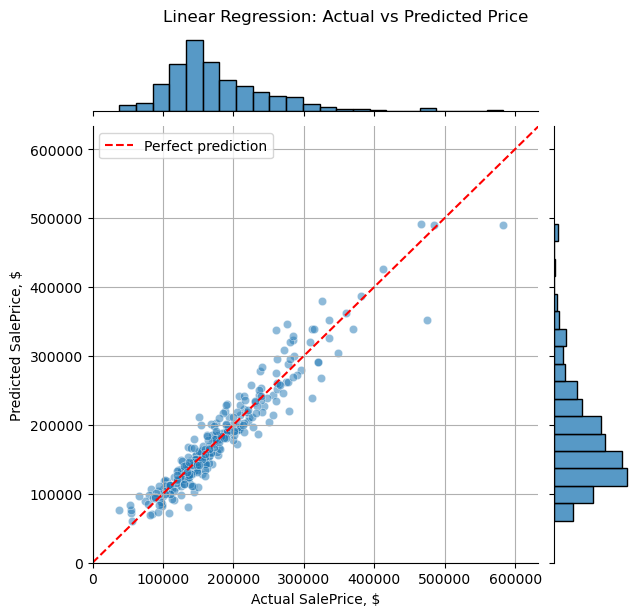

In [70]:
# Actual vs predicted price on validation set
g = sns.jointplot(x=np.expm1(y_val), y=np.expm1(y_pred_val), kind='scatter', alpha=0.5)

lims = [0, max(np.expm1(y_val).max(), np.expm1(y_pred_val).max()) + 50000]
g.ax_joint.set_xlim(lims)
g.ax_joint.set_ylim(lims)

g.ax_joint.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect prediction')
g.ax_joint.legend()

g.ax_joint.set_xlabel('Actual SalePrice, $')
g.ax_joint.set_ylabel('Predicted SalePrice, $')

plt.suptitle('Linear Regression: Actual vs Predicted Price', y=1.02)
plt.grid(True)
plt.show()

> The model performs well in the $100,000–250,000 range where most validation set observations are concentrated. Larger deviations are visible for cheaper homes (left side) and expensive homes (right side), reflecting the right-skewed price distribution and sparse data at the extremes.

### Linear Model Cross-Validation

In [71]:
from sklearn.model_selection import cross_val_score

# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lr_cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
lr_cv_rmse = -lr_cv_scores

print(f"CV RMSE scores: {lr_cv_rmse.round(4)}")
print(f"Mean CV RMSE: {lr_cv_rmse.mean():.4f}")
print(f"Std CV RMSE: {lr_cv_rmse.std():.4f}")

CV RMSE scores: [0.1423 0.1203 0.1344 0.1343 0.1279]
Mean CV RMSE: 0.1318
Std CV RMSE: 0.0074


> The gap between train and CV RMSE (0.0882 vs 0.1318) is consistent across all 5 folds, confirming *mild overfitting*.
>
> Ridge and Lasso regularizatios will be applied to reduce this gap.

## Improving Linear Regression with Regularization
### LRidge

In [72]:
from sklearn.linear_model import RidgeCV

# Step 1 – Broad search
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100], cv=5))  # default=(0.1, 1.0, 10.0)
])

ridge_pipeline.fit(X_train, y_train)
best_alpha_broad = ridge_pipeline.named_steps['model'].alpha_
print(f"Step 1 - Best alpha: {best_alpha_broad}")

Step 1 - Best alpha: 10.0


In [73]:
# Step 2 – Narrow search around best alpha from Step 1
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=np.linspace(best_alpha_broad / 2, best_alpha_broad * 3, 20), cv=5))
])
ridge_pipeline.fit(X_train, y_train)
print(f"Step 2 - Best alpha: {ridge_pipeline.named_steps['model'].alpha_}")

Step 2 - Best alpha: 18.157894736842106


In [74]:
# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_ridge_train = ridge_pipeline.predict(X_train)
    y_pred_ridge_val = ridge_pipeline.predict(X_val)
    
ridge_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
ridge_rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_ridge_val))

print(f"Ridge RMSE:\nTrain: {ridge_rmse_train:.4f}")
print(f"Validation: {ridge_rmse_val:.4f}")

Ridge RMSE:
Train: 0.1011
Validation: 0.1172


In [75]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge'],
    'Train RMSE': [lr_rmse_train, ridge_rmse_train],
    'Validation RMSE': [lr_rmse_val, ridge_rmse_val]
}).set_index('Model')

comparison['Gap'] = (comparison['Train RMSE'] - comparison['Validation RMSE']).abs()
print(comparison.round(4).T)

Model            Linear Regression   Ridge
Train RMSE                  0.0882  0.1011
Validation RMSE             0.1283  0.1172
Gap                         0.0401  0.0161


> Ridge regression outperforms Linear Regression on the validation set (RMSE 0.1172 vs 0.1283) while reducing the train-validation gap from 0.0401 to 0.0161, confirming that L2 regularization successfully reduced overfitting.

Lasso will be applied next, as it can perform automatic feature selection and potentially improve model interpretability further.

### Lasso

In [76]:
from sklearn.linear_model import LassoCV

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
print(f"Best alpha: {lasso_pipeline.named_steps['model'].alpha_}")

Best alpha: 0.0006623818472860814


In [77]:
# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_lasso_train = lasso_pipeline.predict(X_train)
    y_pred_lasso_val = lasso_pipeline.predict(X_val)

lasso_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
lasso_rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_lasso_val))

print(f"Lasso RMSE:\nTrain: {lasso_rmse_train:.4f}")
print(f"Validation: {lasso_rmse_val:.4f}")

Lasso RMSE:
Train: 0.1042
Validation: 0.1162


In [78]:
comparison.loc['Lasso'] = [lasso_rmse_train, lasso_rmse_val, abs(lasso_rmse_train - lasso_rmse_val)]
print(comparison.round(4))

                   Train RMSE  Validation RMSE     Gap
Model                                                 
Linear Regression      0.0882           0.1283  0.0401
Ridge                  0.1011           0.1172  0.0161
Lasso                  0.1042           0.1162  0.0120


> Lasso regression achieves the highest train RMSE (0.1042) but outperforms both Linear Regression and Ridge on the validation set (0.1162), suggesting better generalization.
>
> The smallest train-validation gap (0.0120) confirms that Lasso's automatic feature selection effectively reduced overfitting.

#### Feature Importance

In [79]:
lasso_feature_names = ridge_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [80]:
lasso_coef = lasso_pipeline.named_steps['model'].coef_

In [81]:
lasso_coef_df = pd.DataFrame({
    'feature': lasso_feature_names,
    'coefficient': lasso_coef
}).sort_values('coefficient', key=abs, ascending=False)


lasso_coef_df['feature'] = lasso_coef_df['feature'].apply(lambda x: x.split('__')[-1])

In [82]:
print(lasso_coef_df.head(20))

                  feature  coefficient
7               GrLivArea     0.142489
161  Neighborhood_Crawfor     0.107087
103          SaleType_New     0.096781
177  Neighborhood_StoneBr     0.072977
2             OverallQual     0.072669
24               HouseAge    -0.063619
94         Functional_Typ     0.062638
171  Neighborhood_NridgHt     0.059263
125           MSZoning_FV     0.057734
3             OverallCond     0.054725
243  SaleCondition_Normal     0.054602
6             TotalBsmtSF     0.051640
127           MSZoning_RL     0.050305
36        BsmtExposure_Gd     0.049628
131   Exterior1st_BrkFace     0.047901
165  Neighborhood_MeadowV    -0.047657
237          CentralAir_Y     0.045934
196        BldgType_Twnhs    -0.039445
15             GarageCars     0.037139
224      Foundation_PConc     0.035590


In [83]:
print(f"Zeroed out features: {(lasso_coef == 0).sum()} out of {len(lasso_coef)} ({((lasso_coef == 0).sum()/len(lasso_coef) * 100).round(0)}%)")
print(f"Retained features: {(lasso_coef != 0).sum()}")

Zeroed out features: 161 out of 245 (66.0%)
Retained features: 84


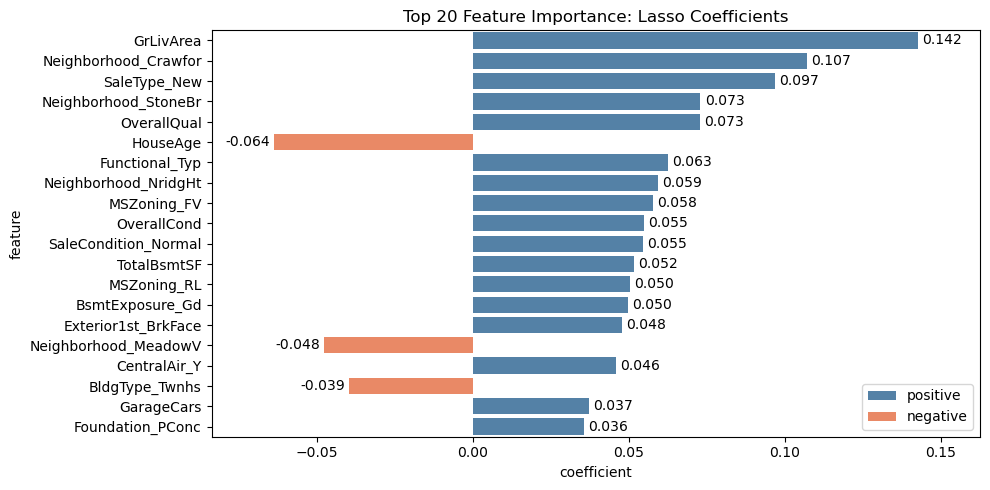

In [84]:
# Feature importance
fig, ax = plt.subplots(figsize=(10, 5))

lasso_coef_df['direction'] = lasso_coef_df['coefficient'].apply(
    lambda x: 'positive' if x > 0 else 'negative'
)

sns.barplot(lasso_coef_df.head(20), x='coefficient', y='feature', hue='direction', 
            palette={'positive': 'steelblue', 'negative': 'coral'}, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

ax.set_xlim(lasso_coef_df.head(20)['coefficient'].min() - 0.02,
            lasso_coef_df.head(20)['coefficient'].max() + 0.02)

plt.title('Top 20 Feature Importance: Lasso Coefficients')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Feature Importance Analysis

161 out of 245 features (66.0%) were zeroed out by Lasso regression, while 84 features were retained.

**Top positive predictors** — features that increase sale price:
* `GrLivArea` (0.142) — the strongest predictor, confirming EDA findings 
* `Neighborhood_Crawfor`(0.107), `Neighborhood_StoneBr`(0.73), `Neighborhood_NridgHt`(0.059) — premium neighborhoods identified in EDA
* `SaleType_New` (0.097) — brand new homes
* `OverallQual` (0.073) — overall material and finish of the house

**Top negative predictors** — features that decrease sale price:
* `HouseAge` (-0.064) — older homes sell for less
* `Neighborhood_MeadowV` (-0.048) — one of the least expensive neighborhoods identified in EDA
* `BldgType_Twnhs` (-0.039) — townhouses sell for less than single-family detached homes (`1Fam`), which is the reference category (see the cell below)

In [85]:
# Find the reference category for BldgType
bldg_categories = sorted(df_train['BldgType'].unique())
print(f"Reference category: {bldg_categories[0]}")

Reference category: 1Fam


## Inference & Predictions

In [86]:
# Predictions on test set

# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_test = lasso_pipeline.predict(df_test)
    y_pred_test_prices = np.expm1(y_pred_test)
    

comparison_stats = pd.DataFrame({
    'Train Actual': df_train['SalePrice'].describe(),
    'Test Predicted': pd.Series(y_pred_test_prices).describe()
}).round(0).astype(int)

comparison_stats.style.format("{:,}")

,Train Actual,Test Predicted
count,"1,458","1,459"
mean,"180,933","179,012"
std,"79,495","84,629"
min,"34,900","51,887"
25%,"129,925","125,515"
50%,"163,000","156,807"
75%,"214,000","211,387"
max,"755,000","1,501,269"


Key statistics are well aligned across both datasets:
- mean: 180,933 vs 179,012
- median: 163,000 vs 156,806
- interquartile range: 129,925–214,000 vs 125,515–211,388

> The model captures the overall price distribution well. 
    
The standard deviation is slightly higher for predictions (84,629 vs 79,495), indicating wider spread in the test predictions.

In [87]:
# Index of the house with the max predicted price
max_price_idx = y_pred_test_prices.argmax()

print(f"The house with the max predicted price of ${y_pred_test_prices[max_price_idx]:,.0f}")
print(df_test.iloc[max_price_idx][['GrLivArea', 'BldgType', 'OverallQual', 'Neighborhood', 'HouseAge', 'TotalBsmtSF', 'GarageCars']])

The house with the max predicted price of $1,501,269
GrLivArea          5095
BldgType           1Fam
OverallQual          10
Neighborhood    Edwards
HouseAge              0
TotalBsmtSF      5095.0
GarageCars          3.0
Name: 1089, dtype: object


In [88]:
print(f"Max GrLivArea in train set: {df_train['GrLivArea'].max()}")
print(f"Max GrLivArea in test set: 5095")
print(f"\nHouses in train set with GrLivArea > 4000:")
print(df_train[df_train['GrLivArea'] > 4000][['GrLivArea', 'SalePrice', 'OverallQual', 'HouseAge']])

Max GrLivArea in train set: 4476
Max GrLivArea in test set: 5095

Houses in train set with GrLivArea > 4000:
      GrLivArea  SalePrice  OverallQual  HouseAge
691        4316     755000           10        13
1182       4476     745000           10        11


The maximum predicted price (1,501,279) corresponds to a house with `GrLivArea` = 5,095 sqft — larger than any home in the training set 
(max: 4,476 sqft). The property also features a full basement matching the living area (`TotalBsmtSF` = 5,095 sqft), a 3-car garage, and the 
highest quality rating (`OverallQual` = 10). However, it is located in Edwards — a below-average neighborhood with a median price of 128,220 
in the training data. 
    
The two most comparable homes in the training set (GrLivArea > 4,000 sqft, OverallQual = 10) sold for approximately 750,000 — roughly half the 
predicted price. The model has not seen homes of this size during training, making this prediction unreliable despite the exceptional property characteristics.

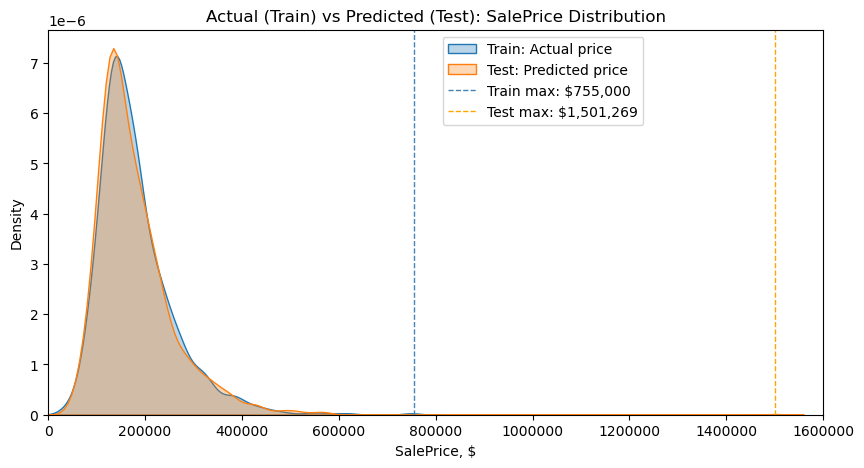

In [89]:
# Actual vs predicted SalePrice
plt.figure(figsize=(10, 5))

sns.kdeplot(df_train['SalePrice'], label='Train: Actual price', fill=True, alpha=0.3)
sns.kdeplot(y_pred_test_prices, label='Test: Predicted price', fill=True, alpha=0.3)

plt.xlabel('SalePrice, $')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Actual (Train) vs Predicted (Test): SalePrice Distribution')

# Max price lines
max_train_price = df_train["SalePrice"].max()
max_test_price = y_pred_test_prices.max()

plt.axvline(max_train_price, color='steelblue', linestyle='dashed', linewidth=1, label=f'Train max: ${max_train_price:,.0f}')
plt.axvline(max_test_price, color='orange', linestyle='dashed', linewidth=1, label=f'Test max: ${max_test_price:,.0f}')

plt.xlim(0, 1600000)
plt.legend(bbox_to_anchor=(0.5, 1), loc='upper left')
plt.show()

> The predicted price distribution closely mirrors the actual train distribution, with both peaking around 150,000–200,000 and showing a similar right skew. This confirms that the model generalizes well to unseen data.
>
> The predicted distribution has a longer right tail due to one outlier (`GrLivArea` = 5,095 sqft, predicted price 1,501,279). This home is larger than any property in the training set, making this particular prediction unreliable.

## Conclusion

This project demonstrates the full ML pipeline for house price prediction. 

All three models were evaluated on the validation set.

| Model | Train RMSE | Validation RMSE | Gap |
|-------|-----------|-----------------|-----|
| Linear Regression | 0.0882 | 0.1283 | 0.0401 |
| Ridge | 0.1011 | 0.1172 | 0.0161 |
| Lasso | 0.1042 | 0.1162 | 0.0120 |
    
**Lasso regression** was selected as the best model (validation RMSE: 0.1162) due to its ability to reduce overfitting (smallest train-validation gap: 0.0120) and perform automatic feature selection, retaining only 84 out of 245 features.

#### Key Findings
- Living area (`GrLivArea`) and overall quality (`OverallQual`) are the strongest positive predictors of sale price
- Neighborhood has a significant impact: premium neighborhoods (`Neighborhood_StoneBr`, `Neighborhood_NridgHt`, `Neighborhood_Crawfor`) are associated with substantially higher prices
- New construction (`SaleType_New`) tends to sell for higher prices
- `HouseAge` has the strongest negative effect: each additional year of age is associated with a lower sale price
- `Neighborhood_MeadowV` and townhouse building type (`BldgType_Twnhs`) are associated with lower prices compared to the reference categories

#### Limitations

The model has two key limitations identified during analysis:

1. **Out-of-range predictions:** the model is unreliable for homes larger than those in the training set (max: 4,476 sqft). This is demonstrated by the prediction of 1,501,279 for a 5,095 sqft home — roughly twice the price of comparable homes in the training data.

2. **Non-linear relationships:** the relationship between `HouseAge` and `SalePrice` is non-linear (better described by a degree-3 polynomial),    which a linear model cannot fully capture. This leads to less accurate predictions for very new and very old homes.

#### Future Improvements

The analysis revealed a non-linear relationship between `HouseAge` and `SalePrice`, which a linear model cannot fully capture. A follow-up project will focus on comparing Polynomial Regression, Step Functions, and Regression Splines with the goal of incorporating the best method into this pipeline.

In [90]:
# Run this cell to generate files required by the follow-up project

try:
    import joblib
except ImportError:
    !pip install joblib
    import joblib

# Export cleaned datasets for future analysis: modeling Nonlinear Relationships
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv', index=False)

# Save preprocessor configuration
joblib.dump(preprocessor, 'preprocessor_config.pkl')

['preprocessor_config.pkl']